<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/SVD(%ED%8A%B9%EC%9D%B4%EA%B0%92_%EB%B6%84%ED%95%B4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mlt
import seaborn as sns

In [12]:
# 넘파이의 svd 모듈 임포트
from numpy.linalg import svd

# 4x4 랜덤 행렬 a 생성
np.random.seed(121)
a = np.random.randn(4,4)
print(np.round(a,3))


[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]


이렇게 생성된 a 행렬에 SVD를 적용해 U,Sigma,Vt를 도출하겠습니다.

Sigma 행렬의 경우, $A=U\Sigma V^T$에서 $\Sigma$ 행렬을 나타내며, $\Sigma$ 행렬의 경우 행렬의 대각에 위치한 값만 0이 아니고, 그렇지 않은 경우는 모두 0이므로 0이 아닌 값의 경우만 1차원 행렬로 표현합니다.

SVD 분해는 numpy.linalg.svd에 파라미터로 원본 행렬을 입력하면 U 행렬, Sigma 행렬, V 전치 행렬을 반환합니다.

In [13]:
U,Sigma,Vt=svd(a)
print(U.shape,Sigma.shape,Vt.shape)
print(f'U matric:\n{np.round(Sigma,3)}')
print(f'V transpose matrix:\n{np.round(Vt,3)}')

(4, 4) (4,) (4, 4)
U matric:
[3.423 2.023 0.463 0.079]
V transpose matrix:
[[ 0.041  0.224  0.786 -0.574]
 [-0.2    0.562  0.37   0.712]
 [-0.778  0.395 -0.333 -0.357]
 [-0.593 -0.692  0.366  0.189]]


In [14]:
# 다시 원본 행렬로 복원
# Sigma의 경우 0이 아닌 값만 1차원으로 추출했으므로 다시 0을 포함한 대칭행렬로 변환한 뒤에 내적을 수행
Sigma_mat = np.diag(Sigma)
a_=np.dot(np.dot(U,Sigma_mat),Vt)
print(np.round(a_,3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]


데이터 세트가 로우 간 의존성이 있을 경우 어떻게 Sigma 값이 변하고, 이에 따른 차원 축소가 진행될 수 있는지 알아보겠습니다.

In [15]:
# 의존성 부여를 위해 a 행렬의 3번째 로우를 '첫 번째 로우 + 두 번쨰 로우'로 업데이트
a[2]=a[0]+a[1]
a[3]=a[0]
print(np.round(a,3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.542  0.899  1.041 -0.073]
 [-0.212 -0.285 -0.574 -0.44 ]]


이제 a 행렬은 이전과 다르게 로우 간 관계가 매우 높아졌습니다. 이 데이터를 SVD로 다시 분해해 보겠습니다.

In [16]:
# 다시 SVD를 수행해 Sigma 값 확인
U, Sigma,Vt = svd(a)
print(U.shape,Sigma.shape,Vt.shape)
print(f'Sigma Value:{np.round(Sigma,3)}')


(4, 4) (4,) (4, 4)
Sigma Value:[2.663 0.807 0.    0.   ]


이전과 차원은 같지만  Sigma  값 중 2개가 0으로 변했습니다.

즉, 선형 독립인 로우 벡터의 개수가 2개라는 의미입니다.

In [17]:
# U 행렬의 경우는 Sigma와 내적을 수행하므로 Sigma의 앞 2행에 대응되는 앞 2열만 추출
U_=U[:,:2]
Sigma_=np.diag(Sigma[:2])

# V 전치 행렬의 경우는 앞 2행만 추출
Vt_=Vt[:2]
print(U_.shape,Sigma_.shape,Vt_.shape)

# U ,Sigma.Vt의 내적을 수행하며, 다시 원본 행렬 복원
a_ = np.dot(np.dot(U_,Sigma_),Vt_)
print(np.round(a_,3))

(4, 2) (2, 2) (2, 4)
[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.542  0.899  1.041 -0.073]
 [-0.212 -0.285 -0.574 -0.44 ]]


이번에는 Truncated SVD를 이용해 행렬을 분해해 보겠습니다. Truncated SVD는 $\Sigma$ 행렬에 있는 대각원소, 즉 특이값 중 상위 일부 데이터만 추출해 분해하는 방식입니다. 이렇게 분해하면 인위적으로 더 작은 차원의 $U,\Sigma,V^T$로 분해되기 때문에 원본 행렬을 정확하게 근사할 수는 없습니다.

하지만 데이터 정보가 압축되어 분해됨에도 불구하고 상당한 수준으로 원본 행렬을 근사할 수 있습니다.

원래 차원의 차수에 가깝게 잘라낼수록(Turncate)원본 행렬에 더 가깝게 복원할 수 있습니다.

In [18]:
from scipy.sparse.linalg import svds
from scipy.linalg import svd

# 원본 행렬을 출력하고 SVD를 적용할 경우 U,Sigma,Vt의 차원 확인
np.random.seed(121)
matrix=np.random.random((6,6))
print(f'원본 행렬:\n{matrix}')

U,Sigma,Vt = svd(matrix,full_matrices=False)
print(f'\n분해 행렬 차원:{U.shape,Sigma.shape,Vt.shape}')
print(f'\nSigma값 행렬:{Sigma}')

# Turncated SVD로 Sigma 행렬의 특이값을 4개로 하여 Turncated SVD 수행
num_components=4
U_tr,Sigma_tr,Vt_tr=svds(matrix,k=num_components)
print(f'Turncated SVD 분해 행렬 차원:{U_tr.shape,Sigma_tr.shape,Vt_tr.shape}')
print(f'\nTurncated SVD Sigma값 행렬:{Sigma_tr}')
matrix_tr=np.dot(np.dot(U_tr,np.diag(Sigma_tr)),Vt_tr)

print(f'\nTurncated SVD 분해 후 복원 행렬:\n{matrix_tr}')

원본 행렬:
[[0.11133083 0.21076757 0.23296249 0.15194456 0.83017814 0.40791941]
 [0.5557906  0.74552394 0.24849976 0.9686594  0.95268418 0.48984885]
 [0.01829731 0.85760612 0.40493829 0.62247394 0.29537149 0.92958852]
 [0.4056155  0.56730065 0.24575605 0.22573721 0.03827786 0.58098021]
 [0.82925331 0.77326256 0.94693849 0.73632338 0.67328275 0.74517176]
 [0.51161442 0.46920965 0.6439515  0.82081228 0.14548493 0.01806415]]

분해 행렬 차원:((6, 6), (6,), (6, 6))

Sigma값 행렬:[3.2535007  0.88116505 0.83865238 0.55463089 0.35834824 0.0349925 ]
Turncated SVD 분해 행렬 차원:((6, 4), (4,), (4, 6))

Turncated SVD Sigma값 행렬:[0.55463089 0.83865238 0.88116505 3.2535007 ]

Turncated SVD 분해 후 복원 행렬:
[[0.19222941 0.21792946 0.15951023 0.14084013 0.81641405 0.42533093]
 [0.44874275 0.72204422 0.34594106 0.99148577 0.96866325 0.4754868 ]
 [0.12656662 0.88860729 0.30625735 0.59517439 0.28036734 0.93961948]
 [0.23989012 0.51026588 0.39697353 0.27308905 0.05971563 0.57156395]
 [0.83806144 0.78847467 0.93868685 0.72673231 

6x6 행렬을 SVD 분해하면 U, Sigma,Vt가 각각 (6,6)(6,)(6,6) 차원이지만, Turncated SVD 분해하면 각각 (6,4)(4,)(4,6) 으로 각각 분해했습니다.

### 실습

원본 데이터를 Turncated SVD 방식으로 분해된 U * Sigma 행렬에 선형 변환해 생성합니다.

Text(0, 0.5, 'TurncatedSVD Component 2')

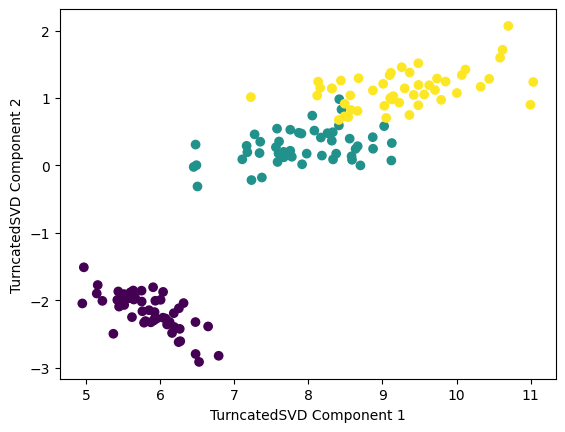

In [22]:
from ast import increment_lineno
from sklearn.decomposition import TruncatedSVD,PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

iris=load_iris()
iris_ftrs = iris.data

# 2개의 주요 컴포넌트로 TruncatedSVD 변환
tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_ftrs)
iris_tsvd = tsvd.transform(iris_ftrs)

# 산점도 2차원으로 TurncatedSVD 변환된 데이터 표현, 품좀은 색깔로 구분
plt.scatter(x=iris_tsvd[:,0],y=iris_tsvd[:,1],c=iris.target)
plt.xlabel('TurncatedSVD Component 1')
plt.ylabel('TurncatedSVD Component 2')

사이킷런의 TruncatedSVD와 PCA 클래스 구현은 모두 SVD를 이용해 행렬을 분해합니다.

붓꽃 데이터를 스케일링으로 변환한 뒤에 TruncatedSVD와 PCA 클래스 변환을 해보면 두 개가 거의 동일함을 알 수 있습니다.

Text(0.5, 1.0, 'PCA Transformed')

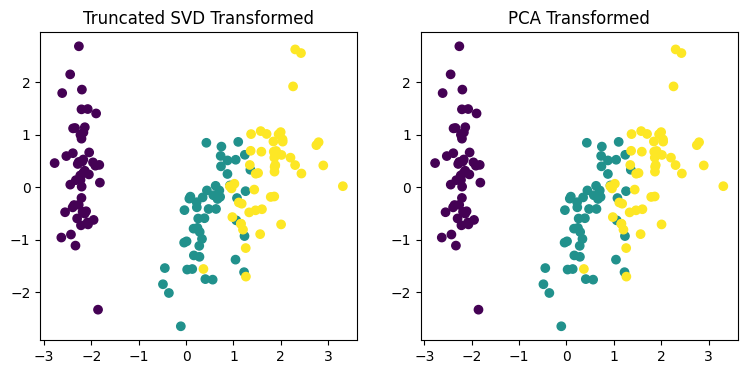

In [23]:
from sklearn.preprocessing import StandardScaler

# 붓꽃 데이터를 StandardScaler로 변환
iris_scaled=StandardScaler().fit_transform(iris_ftrs)

# 스케일링된 데이터를 기반으로 TruncatedSVD 변환 수행
tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_scaled)
iris_tsvd=tsvd.transform(iris_scaled)

# 스케일링된 데이터를 기반으로 PCA 변환 수행
pca = PCA(n_components=2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

# TruncatedSVD 변환 데이터를 왼쪽에, PCA 변환 데이터를 오른쪽에 표현
fig,(ax1,ax2)=plt.subplots(figsize=(9,4),ncols=2)
ax1.scatter(x=iris_tsvd[:,0],y=iris_tsvd[:,1],c=iris.target)
ax2.scatter(x=iris_pca[:,0],y=iris_pca[:,1],c=iris.target)
ax1.set_title('Truncated SVD Transformed')
ax2.set_title('PCA Transformed')

두 개의 변환 행렬 값과 원복 속성별 컴포넌트 비율값을 실제로 서로 비교해 보면 거의 같음을 알 수 있습니다.

In [24]:
print((iris_pca-iris_tsvd).mean())
print((pca.components_- tsvd.components_).mean())

2.33787526375077e-15
-9.020562075079397e-17


모두 0에 가까운 값이므로 2개의 변환이 서로 동일함을 알 수 있습니다. 즉, 데이터 세트가 스케일링으로 데이터 중심이 동일해지면 사이킷런의 SVD와 PCA는 동일한 변환을 수행합니다. 이는 PCA가 SVD 알고리즘으로 구현됐음을 의미합니다.

하지만** PCA는 밀집 행렬(Dense Matrix)(대부분의 요소가 0이 아닌 값을 가지는 행렬)에 대한 변환만 가능**하며

SVD는 희소 행렬(Sparse Matrix)(대부분의 요소가 0인 행렬)에 대한 변환도 가능합니다.

SVD는 PCA와 유사하게 컴퓨터 비전 영역에서 이미지 압축을 통한 패턴 인식과 신호 처리 분야에 사용됩니다.

또한 텍스트의 토픽 모델링 기법인 LSA의 기반 알고리즘 입니다.